# What Is a Time Series?

## Motivation

Time series data are everywhere.

Every day, countless systems generate observations that evolve over time: stock prices fluctuate throughout the trading day, weather stations record temperature every hour, power grids monitor electricity demand every few minutes, and online services collect millions of user interactions every second.

Unlike ordinary tabular datasets, observations in a time series are **not independent**. The order in which measurements occur matters, and values often depend on previous observations. This temporal structure is what makes time series analysis both challenging and fascinating.

The goal of this project is to explore how to analyze, visualize, model, and forecast temporal data using Python. Throughout the following notebooks, we'll build the mathematical intuition behind the methods while implementing them from scratch and using modern Python libraries.

In this first notebook, we'll answer a simple question:

> **What exactly is a time series?**

---

## Definition

A **time series** is a sequence of observations recorded over time.

Mathematically, we often represent a time series as

\[
y_1, y_2, y_3, \ldots, y_t,
\]

where each observation \(y_t\) is associated with a particular instant or period in time.

The observations may be collected at regular intervals (daily temperatures, hourly electricity demand, monthly sales) or at irregular intervals (financial transactions, earthquakes, sensor events).

One of the defining characteristics of time series data is that **the order of the observations is meaningful**. Rearranging the values changes the information contained in the data.

In the next code cells, we'll generate a simple synthetic time series and visualize it.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(seed=42)

# Create a daily date index
dates = pd.date_range(
    start="2025-01-01",
    periods=100,
    freq="D",
)

# Generate a simple synthetic time series
trend = np.linspace(0, 4, len(dates))
seasonality = 2 * np.sin(2 * np.pi * np.arange(len(dates)) / 20)
noise = rng.normal(0, 0.5, len(dates))

series = pd.Series(
    trend + seasonality + noise,
    index=dates,
    name="Synthetic Time Series",
)

series.head()

2025-01-01    0.152359
2025-01-02    0.138446
2025-01-03    1.631604
2025-01-04    2.209528
2025-01-05    1.088212
Freq: D, Name: Synthetic Time Series, dtype: float64

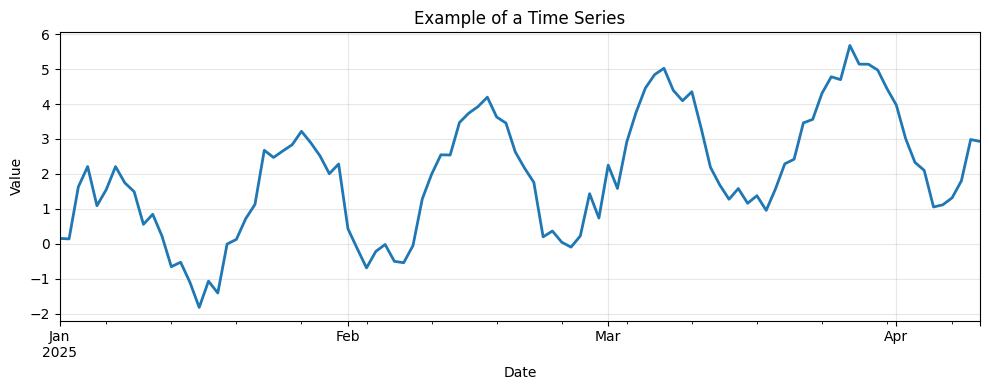

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))

series.plot(ax=ax, linewidth=2)

ax.set_title("Example of a Time Series")
ax.set_xlabel("Date")
ax.set_ylabel("Value")

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()